# Causal Forest / Uplift — Hillstrom Email Marketing

Research question: which customers benefit most from receiving a marketing email? Estimate the conditional average treatment effect (CATE) rather than a single average effect.

Data: Kevin Hillstrom MineThatData E-Mail Analytics Challenge (2008) — customers randomly assigned to a men's email, women's email, or no email.

In [47]:
# econml provides the CausalForestDML estimator; sklearn's forests are the
# nuisance models it uses internally for the Y and T regressions.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

pd.set_option("display.max_columns", None)

## Load data

In [48]:
# Raw Hillstrom email marketing data: one row per customer, with pre-treatment
# covariates, the assigned segment, and post-treatment outcomes (visit/conversion/spend).
data_path = "../data/raw/hillstrom_email.csv"

df = pd.read_csv(data_path)

print(df.shape)
df.head()

(64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


## EDA

1. Structure and missingness
2. Treatment group sizes (`segment`)
3. Outcome variables (`visit`, `conversion`, `spend`) by treatment group — the naive average effect

In [49]:
# No missing values — no imputation strategy needed downstream.
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   segment          64000 non-null  object 
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 5.9+ MB


recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

In [50]:
# Roughly even three-way split (~21.3k each) confirms randomization worked at the group-size level.
df["segment"].value_counts()

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

In [51]:
# Naive average effect (no adjustment for covariates): both email arms outperform
# No E-Mail on all three outcomes. Womens E-Mail conversion (0.0088) vs No E-Mail (0.0057)
# is the comparison we'll validate against the causal forest's ATE later.
df.groupby("segment")[["visit", "conversion", "spend"]].mean()

,visit,conversion,spend
segment,,,
Mens E-Mail,0.182757,0.012531,1.422617
No E-Mail,0.106167,0.005726,0.652789
Womens E-Mail,0.151400,0.008837,1.077202


## Covariate balance check

Confirms randomization worked on pre-treatment covariates, not just on group sizes.

In [52]:
## Group by segment and take the mean of the numeric covariates: recency, history, mens, womens, newbie.
numeric_covariates = ["recency", "history", "mens", "womens", "newbie"]

df.groupby("segment")[numeric_covariates].mean()

,recency,history,mens,womens,newbie
segment,,,,,
Mens E-Mail,5.773642,242.835931,0.550946,0.551415,0.501525
No E-Mail,5.749695,240.882653,0.553224,0.547639,0.501971
Womens E-Mail,5.767850,242.536633,0.548932,0.550101,0.503250


In [53]:
# Normalize by column (segment) so we're comparing proportions, not raw counts.
# All three categorical covariates are flat across arms — no evidence of a randomization issue.
categorical_covariates = ["history_segment", "zip_code", "channel"]

for col in categorical_covariates:
    print(f"\n{col}")
    print(pd.crosstab(df[col], df["segment"], normalize="columns").round(3))


history_segment
segment           Mens E-Mail  No E-Mail  Womens E-Mail
history_segment                                        
1) $0 - $100            0.363      0.357          0.357
2) $100 - $200          0.220      0.227          0.221
3) $200 - $350          0.192      0.190          0.194
4) $350 - $500          0.098      0.100          0.102
5) $500 - $750          0.075      0.078          0.078
6) $750 - $1,000        0.030      0.029          0.028
7) $1,000 +             0.022      0.020          0.020

zip_code
segment    Mens E-Mail  No E-Mail  Womens E-Mail
zip_code                                        
Rural            0.152      0.147          0.149
Surburban        0.446      0.452          0.451
Urban            0.402      0.401          0.400

channel
segment       Mens E-Mail  No E-Mail  Womens E-Mail
channel                                            
Multichannel        0.121      0.122          0.121
Phone               0.434      0.438          0.442
Web    

## Build treatment / outcome / feature matrices

Isolate a single binary comparison — Womens E-Mail vs. No E-Mail — rather than modeling
all three arms at once, since mixing "men's email" and "women's email" into one CATE
model would conflate two different treatments.

In [54]:
# Drop the Mens E-Mail rows entirely so we're left with a clean two-arm comparison.
df_womens_email_eval = df[df['segment'] != 'Mens E-Mail'].copy()

# Binary treatment flag: 1 = received the women's email, 0 = received nothing.
df_womens_email_eval['received_email'] =  np.where(df_womens_email_eval['segment'] == 'Womens E-Mail', 1, 0)

In [55]:
# W = treatment, Y = outcome, X = pre-treatment features only.
# conversion is the outcome, not received_email — keep treatment/outcome/features distinct.
W = df_womens_email_eval['received_email']
Y = df_womens_email_eval['conversion']

# One-hot encode the categorical covariates and concat onto the numeric ones.
# history_segment is a binned version of history, so it's left out to avoid
# feeding the same information into the model twice.
X = pd.concat([
    df_womens_email_eval[numeric_covariates],
    pd.get_dummies(df_womens_email_eval['zip_code'], dtype=int),
    pd.get_dummies(df_womens_email_eval['channel'], dtype=int),
], axis=1)

X.columns = X.columns.str.lower()

In [56]:
# Row-count sanity check before fitting — catches any accidental misalignment
# between W, Y, and X from the steps above.
assert W.shape == Y.shape
assert X.shape[0] == W.shape[0]

## Fit the causal forest

`CausalForestDML` is a double machine learning method: it first partials out how much `X`
predicts `Y` (`model_y`) and how much `X` predicts `W` (`model_t`), then estimates the
treatment effect from the residuals of both. This makes it robust to using flexible ML
models for the nuisance regressions without overfitting bias.

- `model_t` is a classifier and `discrete_treatment=True` because `W` is binary.
- `n_estimators=2000` — CATE estimates and their confidence intervals get less noisy with
  more trees, unlike a standard random forest where accuracy plateaus much earlier.
- `min_samples_leaf=10` — each leaf estimates a local treatment effect, so it needs enough
  observations per leaf for a stable, low-variance estimate.

In [57]:
# discrete_treatment=True is required here — without it econml assumes T is continuous
# and errors when model_t is a classifier ("Cannot use a classifier as a first stage
# model when the target is continuous!").
causal_forest = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=10),
    model_t=RandomForestClassifier(n_estimators=100, min_samples_leaf=10),
    discrete_treatment=True,
    n_estimators=2000,
    min_samples_leaf=10,
    random_state=42,
)

causal_forest.fit(Y, W, X=X)

In [58]:
# Overall ATE ≈ 0.0032, closely matching the naive difference in conversion means
# from the EDA groupby (0.0088 - 0.0057 ≈ 0.0031) — a good consistency check that the
# DML/forest machinery isn't distorting the average effect.
causal_forest.ate(X)

np.float64(0.0032743908538904348)

In [59]:
# p = 0.753, CI [-0.017, 0.023] — the overall ATE is NOT statistically distinguishable
# from zero. Base conversion rate is under 1%, so detecting a ~0.3pp lift needs a lot
# of power, and causal forest's variance estimates are conservative relative to a plain
# two-sample t-test since the method is built for heterogeneity detection, not ATE precision.
causal_forest.ate_inference(X)

## Individual CATEs — is there heterogeneity behind the flat average?

The overall ATE isn't significant, but that alone doesn't rule out meaningful heterogeneity:
there could still be customer segments who respond well to the email, others who are
indifferent or respond negatively, and those effects cancel out in the average. That's the
whole premise of uplift modeling — look past the average to the per-customer effect.

In [60]:
# Per-customer CATE estimates. Mean (0.0032) matches the ATE, as it should — averaging
# all individual effects recovers the overall effect. std (0.0108) is close in magnitude
# to the ATE's own standard error (0.01), so eyeballing this spread alone can't tell us
# whether it reflects real heterogeneity or just per-point estimation noise.
cate_estimates = causal_forest.effect(X)

pd.Series(cate_estimates).describe()

count    42693.000000
mean         0.003274
std          0.010783
min         -0.077966
25%         -0.000812
50%          0.001830
75%          0.007024
max          0.090818
dtype: float64

In [61]:
# Raw per-customer CATE array — used later to build history_bin plots and Qini analysis.
cate_estimates

array([ 0.00436545, -0.00547092,  0.00988588, ..., -0.00101807,
       -0.01147677,  0.01271281], shape=(42693,))

In [62]:
# population_summary() reports the same mean-level statistics as ate_inference, plus the
# distribution of point estimates. std_point (0.011) is still right around the sampling
# noise level (stderr_mean 0.01) — no separate, clean signal that heterogeneity is real
# here; feature importance and a held-out Qini curve are more trustworthy next checks.
effect_inference = causal_forest.effect_inference(X)
effect_inference.population_summary()

In [63]:
# history dominates (61% of splits), recency is a distant second (15%), everything else
# (including all channel/zip dummies) is under 5% each. Importance concentrated on 2
# features rather than spread evenly across all 11 is more consistent with a real,
# if modest, structural signal than with the forest just fitting noise.
pd.Series(causal_forest.feature_importances_, index=X.columns).sort_values(ascending=False)

history         0.610873
recency         0.148237
womens          0.042598
newbie          0.037702
mens            0.032595
rural           0.025774
multichannel    0.024559
phone           0.021943
urban           0.021067
surburban       0.018835
web             0.015818
dtype: float64

## CATE by purchase history

`history` is the dominant driver of heterogeneity, so visualize the estimated treatment
effect as a function of it. Bin into deciles (`qcut`) rather than a raw scatter, since
~42k noisy per-point CATE estimates would just look like a cloud otherwise — averaging
within bins smooths individual-level noise and reveals whether there's a trend.

`duplicates="drop"` is needed because `history` is right-skewed: low-spend customers are
so densely clustered that some decile boundaries land on the same value, which makes
`qcut` error on non-unique bin edges by default. Dropping duplicates just means slightly
fewer than 10 bins at the low end — no rows are lost.

/var/folders/qj/96j3n8f1207254yxvj12_xgc0000gn/T/ipykernel_45463/2868349219.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby("history_bin")["cate"].mean().sort_index().plot(kind="bar")


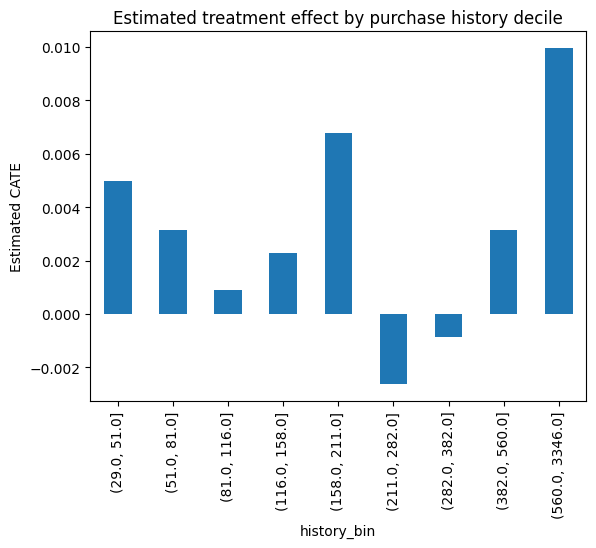

In [64]:
# The resulting shape isn't a clean monotonic trend (positive at both low and high
# history, dips negative in the middle deciles). Bin sizes are ~4.2k each but conversion
# is under 1%, so individual bin means are still noisy — not conclusive without error bars.
# precision=0 rounds bin edges to whole dollars for readable axis labels.
plot_df = X.copy()
plot_df["cate"] = cate_estimates
plot_df["history_bin"] = pd.qcut(plot_df["history"], q=10, duplicates="drop", precision=0)

plot_df.groupby("history_bin")["cate"].mean().sort_index().plot(kind="bar")
plt.ylabel("Estimated CATE")
plt.title("Estimated treatment effect by purchase history decile")

plt.savefig('estimated_treatment_effect_by_purchase_decile.png')

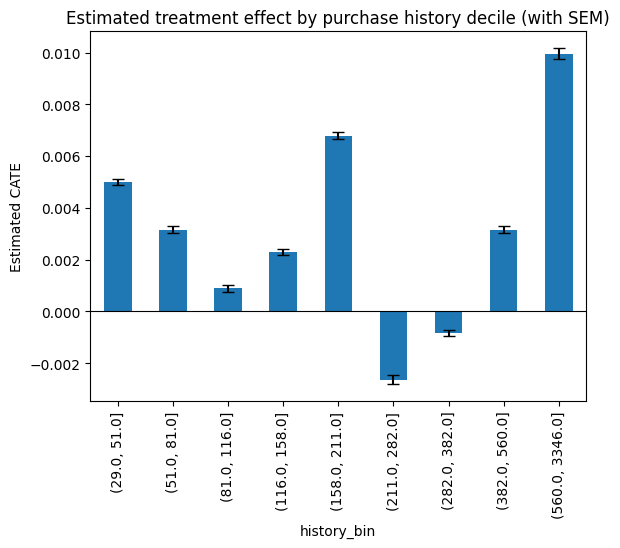

In [65]:
# sem() = standard error of the mean within each bin, used as yerr. If the error bars
# are as tall as the bars themselves, the apparent dip/rise pattern isn't distinguishable
# from noise and shouldn't be read as a real targeting signal.
grouped = plot_df.groupby("history_bin", observed=True)["cate"]
means = grouped.mean().sort_index()
errs = grouped.sem().sort_index()

means.plot(kind="bar", yerr=errs, capsize=4)
plt.ylabel("Estimated CATE")
plt.title("Estimated treatment effect by purchase history decile (with SEM)")
plt.axhline(0, color="black", linewidth=0.8)

## Next: robustness check on the history-decile pattern

Add standard-error bars to the decile plot (`groupby(...).sem()`) before reading anything
into the dip in the middle bins — if the error bars are as tall as the bars, the "trend"
isn't distinguishable from noise.